<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/%ED%8D%BC%EC%85%89%ED%8A%B8%EB%A1%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

퍼셉트론은 신경망(딥러닝)의 기원이 되는 알고리즘입니다.

퍼셉트론은 다수의 신호를 입력으로 받아 하나의 신호를 출력합니다.
퍼셉트론 신호는 ```'흐른다/안 흐른다(1이나 0)'```의 두 가지 값을 가질 수 있습니다.

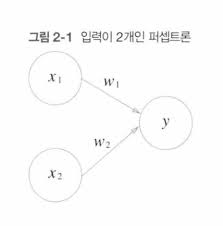

x₁과 x₂는 입력 신호, y는 출력 신호, w₁과 w₂는 <font color="blue">가중치</font>를 뜻합니다.

그림의 원을 뉴런 혹은 **노드**라고 부릅니다. 입력 신호가 뉴런에 보내질 때는 각각 고유한 가중치가 곱해집니다.(w₁x₁,x₂w₂)

뉴런에서 보내온 신호의 총합이 정해진 한계를 넘어설 때만 1을 출력합니다.(이를 '뉴런이 활성화한다'라 표현하기도 합니다.) 그 한계를 임계값이라 하며, ⩉(세타)기호로 나타냅니다.



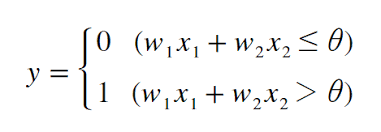

퍼셉트론은 복수의 입력 신호 각각에 고유한 가중치를 부여합니다. 가중치는 각 신호가 결과에 주는 영향력을 조절하는 요소로 작용합니다. **즉, 가중치가 클수록 해당 신호가 그만큼 더 중요함을 뜻합니다.**

2.2 단순한 논리 회로

논리회로의 AND, NAND,OR 게이트를 퍼셉트론 수식으로 표현해보자. 그 전의 위의 식의 **θ를 -b로 치환**하면 퍼셉트론의 동작이 아래 식처럼 됩니다.


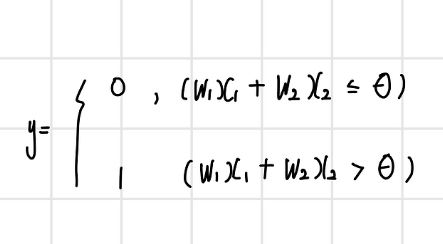

여기서 b를 편향이라하며 w₁,w₂는 그대로 가중치입니다. 퍼셉트론은 입력 신호에 가중치를 곱한 값과 편향을 합하여, 그 값이 0을 넘으면 1을 출력하고 그렇지 않으면 0을 출력합니다. 그럼 넘파이를 사용해서 코드로 구현해봅시다.

In [ ]:
# AND 게이트
import numpy as np

def AND(x1,x2):
  x = np.array([x1,x2]) # 입력
  w = np.array([0.5,0.5]) #가중치
  b = -0.7 # 편향
  tmp=np.sum(w*x)+b
  if tmp <=0:
    return 0
  else:
    return 1


In [ ]:
print(AND(0,0))
print(AND(1,1))

0
1


In [ ]:
# NAND 게이트
import numpy as np

def NAND(x1,x2):
  x = np.array([x1,x2]) # 입력
  w = np.array([-0.5,-0.5]) #가중치
  b = 0.7 # 편향
  tmp=np.sum(w*x)+b
  if tmp <=0:
    return 0
  else:
    return 1


In [ ]:
print(NAND(0,0))
print(NAND(1,1))

1
0


In [ ]:
# OR 게이트
import numpy as np

def OR(x1,x2):
  x = np.array([x1,x2]) # 입력
  w = np.array([0.5,0.5]) #가중치
  b = -0.2 # 편향
  tmp=np.sum(w*x)+b
  if tmp <=0:
    return 0
  else:
    return 1


In [ ]:
print(OR(0,0))
print(OR(0,1))

0
1


편향은 가중치 w1,w2와 기능이 다르다는 사실에 주의합시다. 구체적으로 말하면 w1와 w2는 각 입력 신호가 결과에 주는 영향력(중요도)을 조절하는 매개변수고, 편향은 뉴런이 얼마나 쉽게 활성화(결과로 1을 출력)하느냐를 조정하는 매개변수입니다.

2.4 퍼셉트론의 한계 - XOR 게이트

XOR 게이트는 배타적 논리합이라는 논리 회로입니다.

XOR 게이트를 퍼셉트론으로 구현하려면 가중치 매개변수 값을 어떻게 설정해야할까요?

퍼셉트론은 직선으로 나뉜 두 영역을 만듭니다. 직선으로 나뉜 한쪽 영역은 1을 출력하고 다른 한쪽은 0을 출력합니다. 하지만 XOR 게이트는 직선 하나만으로 나눌 수 없습니다.

퍼셉트론은 직선 하나로 나눈 영역만 표현할 수 있다는 한계가 있습니다. 그래서 다층 퍼셉트론으로 펴현할 수 있습니다. 층을 하나 더 쌓아서 NAND와 OR 게이트의 출력을 AND 게이트의 입력으로 하여 다층 퍼셉트론을 구현하면 XOR 게이트를 수식으로 표현할 수 있습니다.

In [ ]:
def XOR(x1,x2):
  s1=NAND(x1,x2)
  s2=OR(x1,x2)
  y=AND(s1,s2)
  return y

In [ ]:
print(XOR(0,0))
print(XOR(0,1))

0
1


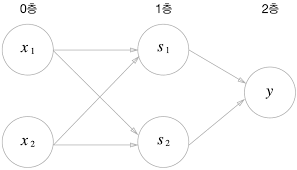

위 그림의 퍼셉트론은 지금까지 본 AND,OR 퍼셉트론과 형태가 다릅니다. 실제로 AND,OR가 단층 퍼셉트론인 데 반해 XOR은 2층 퍼셉트론입니다.